<a href="https://colab.research.google.com/github/lillyzarmehr/DS201_Capstone1/blob/main/Capstone1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### DS201 Capstone 1
#### By Abby and Lilly

In [ ]:
!wget "https://www.fhfa.gov/hpi/download/monthly/hpi_master.csv"

--2026-09-20 15:30:01--  https://www.fhfa.gov/hpi/download/monthly/hpi_master.csv
Resolving www.fhfa.gov (www.fhfa.gov)... 54.92.167.213
Connecting to www.fhfa.gov (www.fhfa.gov)|54.92.167.213|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17154972 (16M) [text/csv]
Saving to: ‘hpi_master.csv.3’

hpi_master.csv.3    100%[===================>]  16.36M  7.81MB/s    in 2.1s    

2026-09-20 15:30:05 (7.81 MB/s) - ‘hpi_master.csv.3’ saved [17154972/17154972]



### 1. Understanding the Data

* When was the data acquired?

Data collection began in January 1975. It was last updated in August 2026. It is continuously collected over time, typically monthly and every housing quarter.

* Where was the data acquired?

The data was acquired from four hundred cities across all fifty states. Indexes are also included for all nine census divisions, the District of Columbia, every Metropolitan Statistical Area (MSA), and Puerto Rico.

* How was the data acquired?

The FHFA reviews repeat mortgage transactions on single-family properties handled by the Federal National Mortgage Association (Fannie Mae) and the Federal Home Loan Mortgage Corporation (Freddie Mac) to compile data for HPI reports on a monthly and quarterly basis. For the master HPI dataset, current and prior data is merged to create an updated historical database.

* What are the attributes of this dataset? / What type of data do these attributes contain?


| Attribute Name | Data Type | Description                                                                                                                               |
| -------------- | --------- | ----------------------------------------------------------------------------------------------------------------------------------------- |
| `hpi_type`     | Nominal   | Categorizes the type of HPI product: traditional, developmental, distress-free, non-metro, or manufactured.                               |
| `hpi_flavor`   | Nominal   | Categorizes how the HPI was calculated: purchase-only, all-transactions, or expanded-data.                                                |
| `frequency`    | Ordinal   | How often a given HPI was reported: monthly or quarterly.                                                                                 |
| `level`        | Nominal   | Describes where the HPI is measured: USA or Census Division, State, MSA (Metropolitan Statistical Area), or Puerto Rico.                  |
| `place_name`   | Nominal   | Name of the specific geographic region for a given HPI: Pacific Division, East North Central Division, Alabama, etc.                      |
| `place_id`     | Nominal   | Contains abbreviations for state names or Core-Based Statistical Area (CBSA) codes for geographic regions.                                |
| `yr`           | Interval  | Year HPI was measured.                                                                                                                    |
| `period`       | Ordinal   | Which quarter or month HPI was measured in (1–4 for quarterly, 1–12 for monthly).                                                         |
| `index_nsa`    | Interval  | Non-seasonally adjusted index. Measures raw house prices.                                                                                 |
| `index_sa`     | Interval  | Seasonally adjusted index. Adjusts house prices for seasonal patterns, such as holiday shopping spikes and winter construction slowdowns. |
| `rstderr`      | Ratio     | Repeat-sales standard error. Measures the uncertainty in HPI estimates.                                                                   |
| `note`         | Nominal   | For some observations, indicates that FHFA did not have enough sales data to estimate HPI.                                                |


### 2. Exploratory Data Analysis

* Present summary statistics for the attributes (mean, median, mode, range, standard deviation, etc.).

In [ ]:
import pandas as pd
hpi = pd.read_csv('hpi_master.csv')

# summary statistics for the numeric data
hpi.describe()

/tmp/ipykernel_4032/1187296311.py:2: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  hpi = pd.read_csv('hpi_master.csv')


,yr,period,index_nsa,index_sa,rstderr
count,186011.000000,186011.000000,186011.000000,96114.000000,58220.000000
mean,2006.159926,2.581014,199.962128,216.670407,2.673249
std,12.004355,1.358702,116.125443,113.512712,2.222155
min,1975.000000,1.000000,18.600000,72.780000,0.000000
25%,1997.000000,2.000000,119.610000,137.290000,1.060000
50%,2007.000000,3.000000,172.130000,187.210000,2.050000
75%,2016.000000,4.000000,241.380000,258.337500,3.600000
max,2026.000000,12.000000,1326.940000,1043.200000,15.750000


In [ ]:
# most frequently occurring levels for each categorical attribute
categories = ['level', 'place_name', 'hpi_type', 'hpi_flavor', 'frequency', 'period']

hpi[categories].mode()

,level,place_name,hpi_type,hpi_flavor,frequency,period
0,MSA,United States,traditional,all-transactions,quarterly,2


* Identify any missing (NA) or empty values and discuss potential strategies to handle them.


In [ ]:
# find missing values in every column
hpi.isna().sum()

,0
hpi_type,0
hpi_flavor,0
frequency,0
level,0
place_name,0
place_id,0
yr,0
period,0
index_nsa,0
index_sa,89897


One strategy to handle the missing values (marked as NaN in pandas) is to drop all the rows with empty values (using hpi.dropna()). This is simple and keeps only the rows with fully complete data, but because there are 89,897 missing values for column index_sa and 127,791 missing values for columns rstderr and note, we would be throwing away nearly all of the data.

Another solution is to drop the columns that have the most missing values. For example, the column called note. This may be more reasonable because note only has values for a few rows, minimizing how much data gets dropped from the dataset.

A final option could be filling in the missing values for index_sa with the mean or median of the column. While this would retain the most data for analysis, it would also flatten the natural variation in the data that misleadingly makes the data look more uniform than actually is. Additionally, the majority of seasonally-adjusted HPIs are calculated for state HPIs. Using the mean and median from seasonally-adjusted state HPIs may then wrongly assume that a house from USA or Census Division level will have a similar seasonally-adjusted HPI.

* If applicable, include visualizations such as histograms, box plots, or scatterplots to showcase trends.


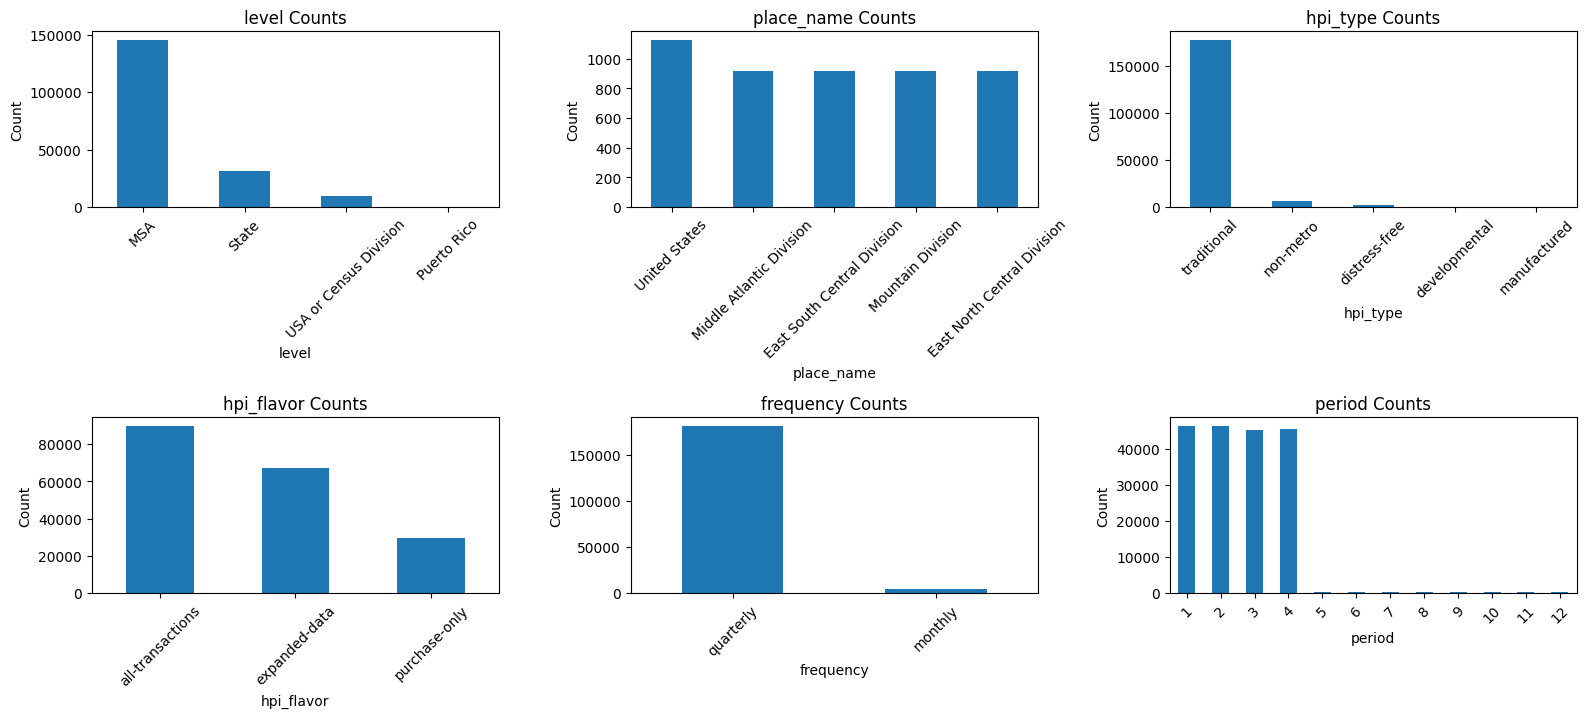

In [ ]:
# categorical variable counts
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(16, 10))

for ax, col in zip(axes.flat, categories):
    counts = hpi[col].value_counts()

    # Restrict place_name to only the top 5
    if col == 'place_name':
        counts = counts.head(5)

    # Sort period numerically
    if col == 'period':
        counts = counts.sort_index()

    counts.plot(kind='bar', ax=ax)
    ax.set_title(f'{col} Counts')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

# Hide the 3 unused subplots
for ax in axes.flat[len(categories):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

**Fig. 1:** These visualizations are consistent with the calculation of the mode. Note that Puerto Rico and many of the numbers corresponding to monthly periods do not show up on the graph due to the y-axis intervals, but values for these levels do exist:

In [ ]:
hpi['place_name'].value_counts()['Puerto Rico']

np.int64(247)

In [ ]:
hpi['period'].value_counts()

,count
period,
2,46337
1,46204
4,45359
3,45291
5,360
6,360
7,350
8,350
9,350


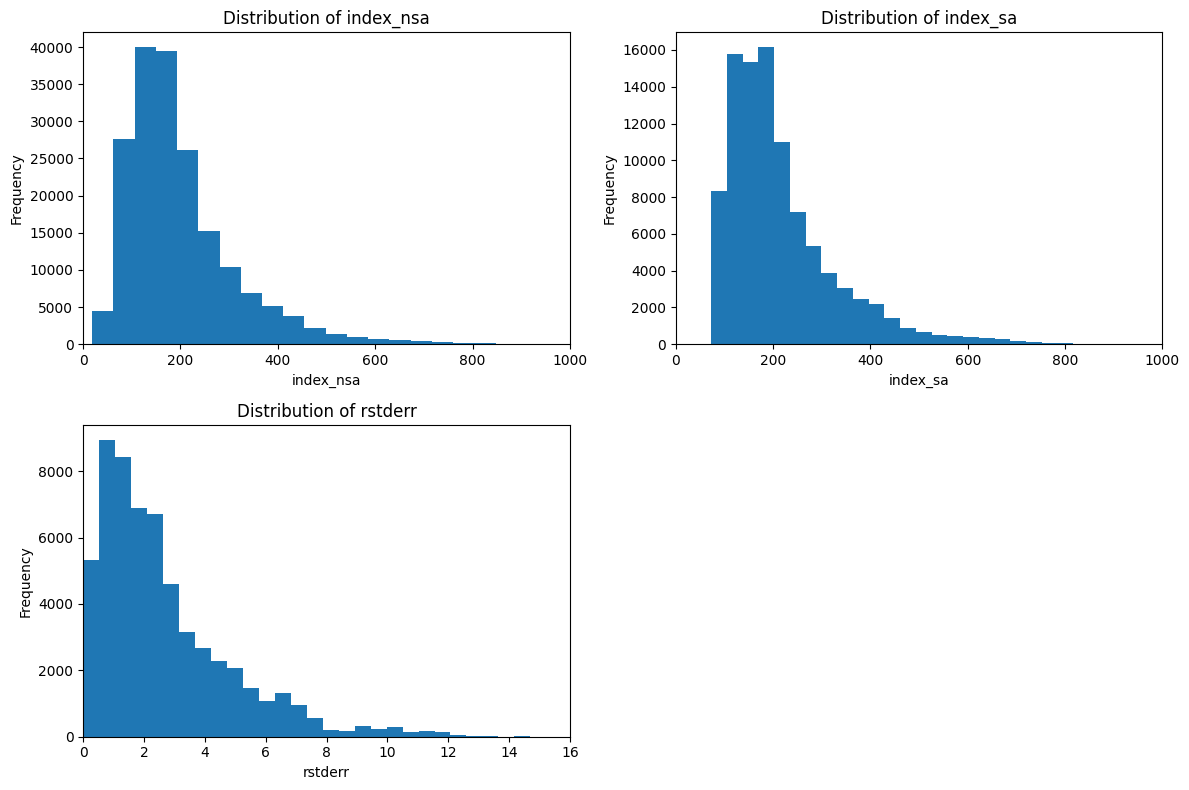

In [ ]:
# histograms for distribution of numeric attributes
numeric = ['index_nsa', 'index_sa', 'rstderr']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

x_ranges = {
    'index_nsa': (0, 1000),
    'index_sa': (0, 1000),
    'rstderr': (0, 16)
}

for ax, col in zip(axes.flat, numeric):
    hpi[col].plot(kind='hist', bins=30, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.set_xlim(x_ranges[col])

# Hide the 1 unused subplot
for ax in axes.flat[len(numeric):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

**Fig. 2:** The three numeric attributes are positively skewed.

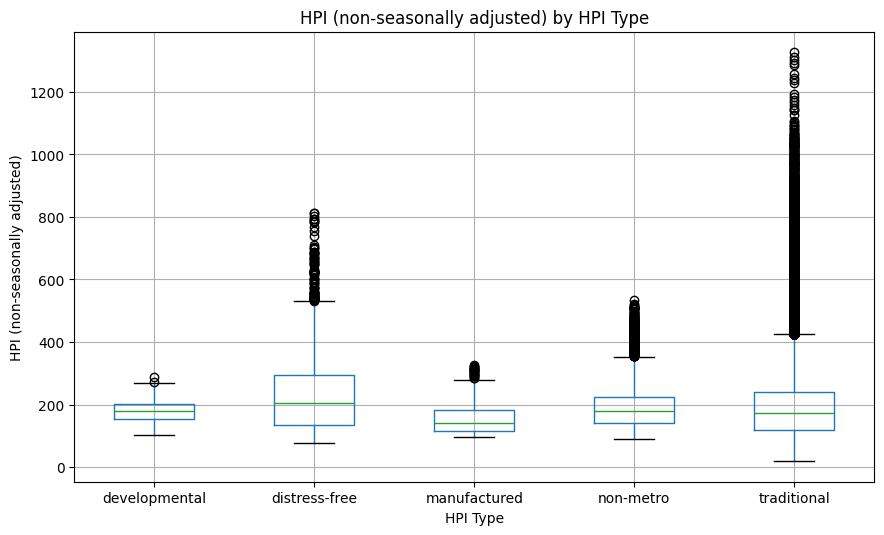

In [ ]:
# boxplots to indicate outliers

hpi.boxplot(column='index_nsa', by='hpi_type', figsize=(10, 6))

plt.title('HPI (non-seasonally adjusted) by HPI Type')
plt.suptitle('')
plt.xlabel('HPI Type')
plt.ylabel('HPI (non-seasonally adjusted)')

plt.show()

**Fig. 3:** Distress-free and traditional HPI types have the largest IQR. HPIs for these HPI types are more spread out. Traditional has the most data points that do not neatly fit into the IQR or its whiskers. These could be outliers or data entry errors.

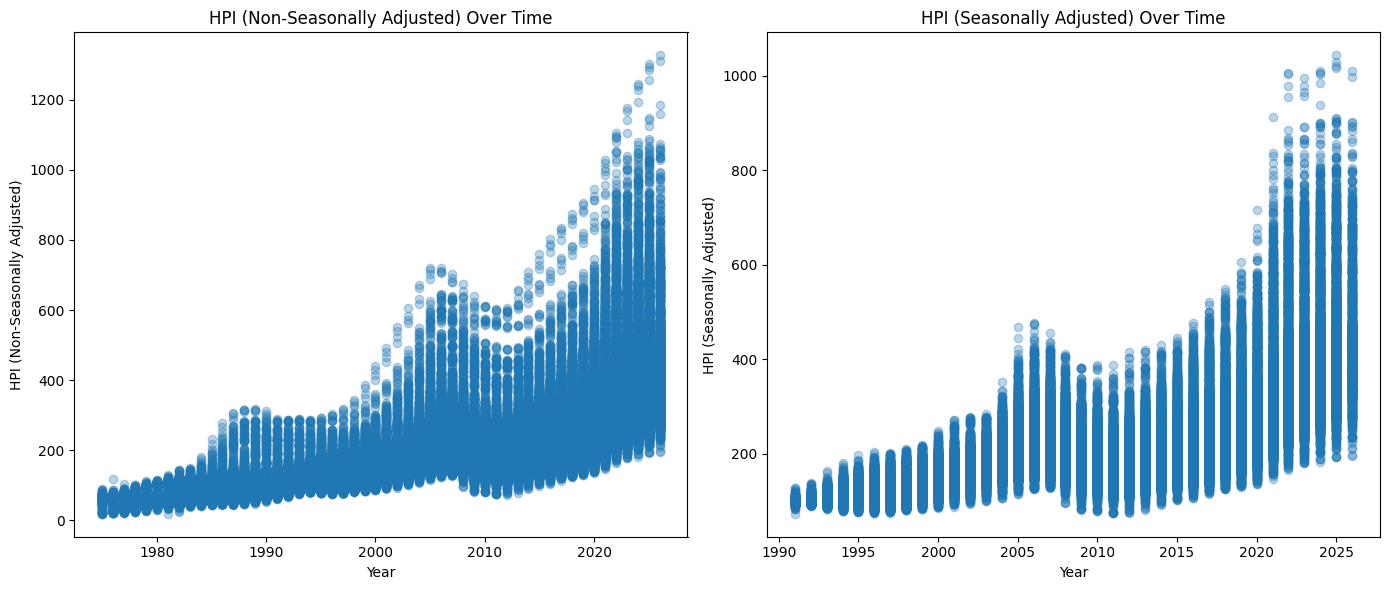

In [ ]:
# scatterplot for year vs. index_nsa
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# non-seasonally adjusted HPI
axes[0].scatter(hpi['yr'], hpi['index_nsa'], alpha=0.3)
axes[0].set_title('HPI (Non-Seasonally Adjusted) Over Time')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('HPI (Non-Seasonally Adjusted)')

# seasonally adjusted HPI
axes[1].scatter(hpi['yr'], hpi['index_sa'], alpha=0.3)
axes[1].set_title('HPI (Seasonally Adjusted) Over Time')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('HPI (Seasonally Adjusted)')

plt.tight_layout()
plt.show()

**Fig. 4:** Regardless of whether or not HPIs were seasonally adjusted, HPI has increased since 1975. Based on these visualizations, the average prices of homes in the U.S. have risen dramatically since 1975. There is a lot more data for non-seasonally adjusted HPIs since the seasonally-adjusted HPIs were mostly calculated only for state listing.

### Visualizations Summary
Overall, the data shows a general upward trend in home prices since 1975. In Fig. 4, this trend is visualized, with some sudden changes reflecting the economy of that time. Between 2007 and 2009, there’s a dip in the market as a result of the financial crisis that occurred, triggering a recession. Another notable change is the sudden uptick in housing prices that began around the COVID-19 pandemic and has continued to rise. This steep acceleration in housing prices shows how a combination of low mortgage rates and remote work during the pandemic increased the demand for housing, in turn increasing the price.

We can also see the trend of the Housing Price Index (HPI) index itself. Fig. 2 shows the majority of houses in the United States cluster around indices 100 and 200. This is mainly the historical data from the 1970s-1990s, when housing prices were lower and increasing by less. Some outliers are skewed towards the right, with extreme outliers reflecting recent hyper-inflated years.


### 3. Expanding Investment Knowledge
* Why would this dataset be useful?

This dataset would be useful because it provides more detailed information about historical trends in real estate on the state level and compares a given listing to other listings in the region. For instance, average_listing_price_yy provides the percent change in average listing price from the same month in the previous year.

* How could it complement the data you are currently analyzing?

This dataset could complement the FHFA HPI dataset by providing more context for a particular state’s average HPI, including how long listings stay up and insights on average listing counts and prices throughout a certain state. This additional information could also be used to better understand and compare patterns in HPI between states.

* Provide a link to the additional dataset.

https://econdata.s3-us-west-2.amazonaws.com/Reports/Core/RDC_Inventory_Core_Metrics_State_History.csv

###